In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]

In [3]:
df = pd.read_csv("housing.csv", header = None, delimiter = r"\s+", names = columns)
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [6]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


array([[<Axes: title={'center': 'ZN'}>]], dtype=object)

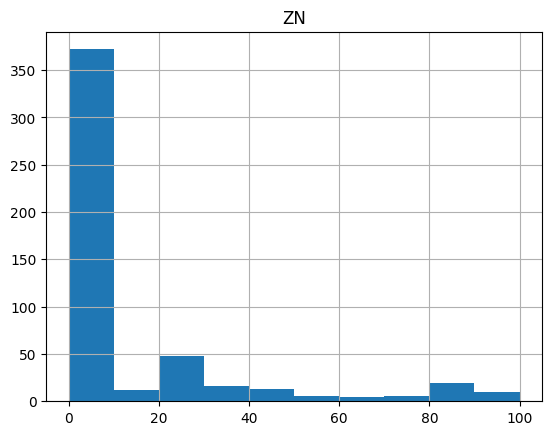

In [7]:
df.hist('ZN')
#ZN - proportion of residential land zoned for lots over 25,000 sq.ft.

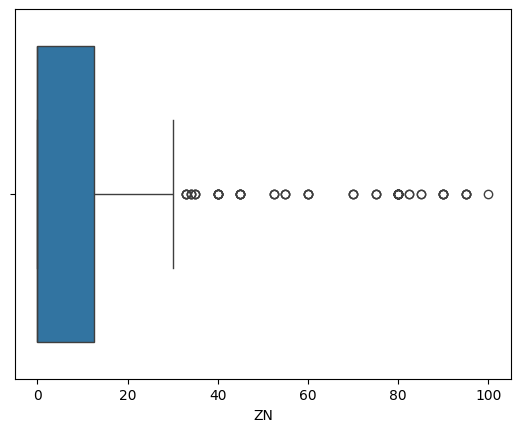

In [8]:
sns.boxplot(x=df['ZN'])
plt.show()
#No need to remove outliers here

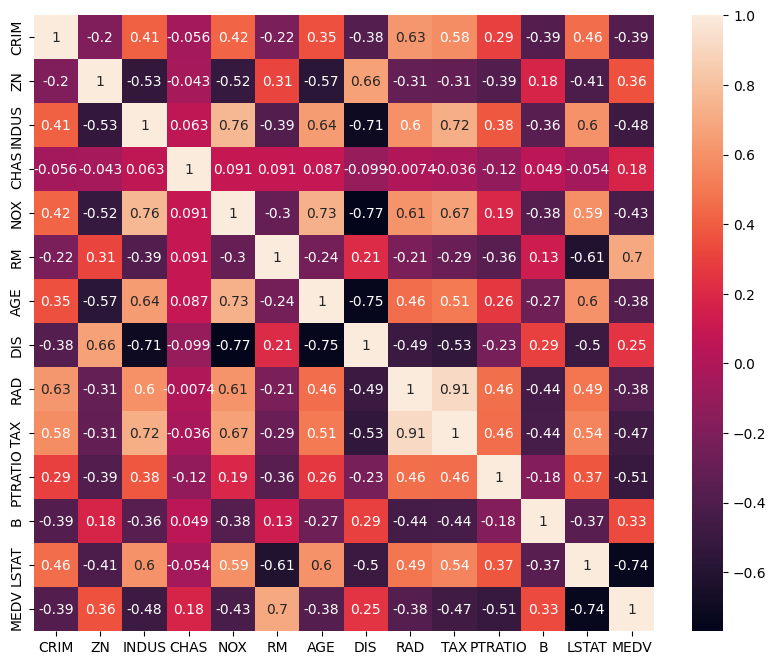

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
X_raw = df.drop('MEDV', axis=1).values
y_raw = df['MEDV'].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2
)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [15]:
X=np.array(X_train_scaled)
y=np.array(y_train)
X_te=np.array(X_test_scaled)

In [16]:
n_samples = X.shape[0]
n_test = X_te.shape[0]
k=6

In [17]:
models=[
    ("knn", {"n_neighbors": 5}),
    ("svr", {"kernel": "rbf"}),
    ("tree", {"max_depth": 5})
]

In [18]:
n_models= len(models)

In [19]:
oof_train= np.zeros((n_samples, n_models))
oof_test= np.zeros((n_test, n_models))

In [20]:
indices= np.arange(n_samples)
np.random.shuffle(indices)

In [21]:
fold_sizes= np.full(k, n_samples // k)
fold_sizes[:n_samples % k] += 1

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [23]:
current= 0
folds= []

In [24]:
for i in fold_sizes:
    start,stop=current,current + i
    folds.append(indices[start:stop])
    current=stop


In [25]:
folds

[array([ 21, 119, 332,  52, 227, 254, 231, 283, 225,  94, 285,  18, 229,
        121,   5,  90,  32, 298, 241, 218, 280,  13, 343, 267, 297,  84,
         48, 291,  40,  60,  89, 169, 105, 113, 177, 278, 246, 197,  47,
        392, 326, 376, 268, 171, 269, 263, 245, 264, 127,  15, 181, 199,
        240, 144, 367, 195, 330, 310, 305, 357, 159, 124, 308,   2, 186,
        106, 176, 266]),
 array([339,  96,  49, 337, 322,  23, 130,  74, 370,  66, 164,  65,  33,
        272, 191, 328, 387,  22, 100, 336, 394, 153, 102, 365, 287,  28,
        247, 226, 398,  91,   1, 359, 210,  73, 399,  19,  27,  41, 187,
        363, 288, 182,  88,  31,  81,   4, 140, 256, 341, 116, 248, 345,
        232,  80, 331, 133, 354, 389, 335, 253, 319, 173,  61, 378, 163,
         20, 203, 142]),
 array([ 62,  25, 396, 211, 338, 132, 282,  79, 371, 270, 380, 212, 214,
        135, 238, 311,  86, 184, 123, 303, 373,  51,  92, 165,  59, 344,
         68, 262, 342, 110, 265, 137, 324,  93, 388,  24, 189,  72, 274,
 

In [29]:
for m_idx, (model_n, params) in enumerate(models):
    test_p= np.zeros((n_test, k))
    for i in range(k):
        val_idx= folds[i]
        train_idx= np.concatenate([folds[j] for j in range(k)
                                      if j != i])
        X_train= X[train_idx]
        y_train= y[train_idx]
        X_fold_val = X[val_idx]
        if model_n=="knn":
            model = KNeighborsRegressor(**params)
        elif model_n=="svr":
            model = SVR(**params)
        elif model_n== "tree":
            model = DecisionTreeRegressor(**params)
        model.fit(X_train, y_train)
        oof_train[val_idx, m_idx] = model.predict(X_fold_val)
        test_p[:, i] = model.predict(X_te)
    oof_test[:, m_idx] = test_p.mean(axis=1)

In [32]:
oof_test

array([[23.74333333, 24.59440801, 24.35969945],
       [23.35666667, 23.74611922, 22.86204584],
       [17.83      , 17.31031731, 18.41391166],
       [15.51333333, 17.04220125, 17.49100822],
       [13.18666667, 14.01625419, 15.60917952],
       [25.14333333, 24.6654808 , 27.33192168],
       [21.06666667, 20.96976952, 20.76980046],
       [16.96333333, 15.81808507, 16.37796284],
       [33.1       , 31.94372741, 44.75982143],
       [22.83333333, 21.57999122, 21.26664051],
       [22.43      , 21.99847631, 20.76980046],
       [30.20333333, 26.92941561, 29.33192008],
       [19.81      , 18.43204641, 20.50585309],
       [ 9.27      , 14.2822486 , 15.099574  ],
       [36.7       , 32.56146205, 48.84049242],
       [ 9.42333333, 13.03927963,  9.22421685],
       [19.11333333, 19.10151985, 15.49851662],
       [20.11666667, 22.61598403, 21.2985703 ],
       [39.4       , 29.22956245, 28.50619288],
       [23.25666667, 24.25112022, 22.86204584],
       [32.30666667, 27.57335221, 32.998

In [31]:
oof_train

array([[26.64      , 25.05474234, 47.8375    ],
       [21.66      , 21.79469277, 19.92222222],
       [20.54      , 19.38352292, 20.23548387],
       ...,
       [13.88      , 16.02324429, 16.43846154],
       [27.42      , 26.34417915, 23.77261905],
       [21.46      , 20.83031486, 20.268     ]])

In [33]:
def add_bias(X_mat):
    return np.c_[np.ones(X_mat.shape[0]), X_mat]


In [ ]:
'''from sklearn.linear_model import LinearRegression
meta_model = LinearRegression()
meta_model.fit(otr, y)
final= meta_model.predict(ote)'''

In [34]:
X_train_meta= add_bias(oof_train)
X_test_meta= add_bias(oof_test)

In [35]:
XT = X_train_meta.T

In [36]:
beta = np.linalg.pinv(XT.dot(X_train_meta)).dot(XT).dot(y)


In [37]:
y_final_pred = X_test_meta.dot(beta)

In [38]:
mse_final = np.mean((y_test - y_final_pred) ** 2)
print(f"MSE: {mse_final:.5f}")

MSE: 6.97244
